# Option Payoffs

This notebook introduces the basic payoff shapes for calls and puts. These graphs are useful because most of the later project work, including Greeks and hedging error, starts from the same nonlinear payoff structure.

The setup here is deliberately simple: one strike price, one premium, and a range of possible stock prices at expiry.


## Setup

The strike is set at 100 and the premium is set at 5. The stock price at expiry is varied from 50 to 150 so the payoff shape is visible on both sides of the strike.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.payoffs import (
    call_payoff,
    put_payoff,
    long_call_profit,
    long_put_profit,
    breakeven_long_call,
    breakeven_long_put,
)

figures_dir = PROJECT_ROOT / "figures"
figures_dir.mkdir(exist_ok=True)


In [2]:
strike = 100.0
premium = 5.0

stock_prices = np.linspace(50, 150, 501)

call_payoffs = call_payoff(stock_prices, strike)
put_payoffs = put_payoff(stock_prices, strike)

call_profits = long_call_profit(stock_prices, strike, premium)
put_profits = long_put_profit(stock_prices, strike, premium)

call_breakeven = breakeven_long_call(strike, premium)
put_breakeven = breakeven_long_put(strike, premium)

print(f"Long call breakeven: {call_breakeven:.2f}")
print(f"Long put breakeven: {put_breakeven:.2f}")


Long call breakeven: 105.00
Long put breakeven: 95.00


## Plotting Helper

The same plotting function is used for each figure so the outputs have a consistent format.


In [3]:
def save_line_plot(x, y, title, ylabel, filename, strike=None, breakeven=None):
    plt.figure(figsize=(8, 5))
    plt.plot(x, y)
    plt.axhline(0, linestyle="--", linewidth=1)

    if strike is not None:
        plt.axvline(strike, linestyle="--", linewidth=1)
        plt.text(strike, min(y), f" Strike = {strike:.0f}", va="bottom")

    if breakeven is not None:
        plt.axvline(breakeven, linestyle=":", linewidth=1)
        plt.text(breakeven, max(y) * 0.65, f" Breakeven = {breakeven:.0f}", va="center")

    plt.title(title)
    plt.xlabel("Stock Price at Expiry")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    output_path = figures_dir / filename
    plt.savefig(output_path, dpi=160)
    plt.show()

    print(f"Saved: {output_path}")


## Long Call Payoff

A long call has no payoff when the stock finishes below the strike. Once the stock finishes above the strike, the payoff increases dollar-for-dollar with the stock price.


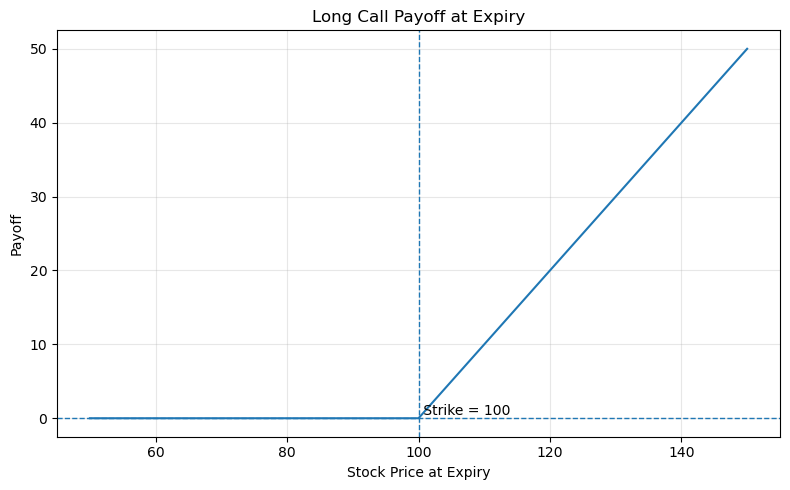

Saved: /Users/kedarvanikar/Downloads/option-market-frictions-hedging-error-lab-phase-1/figures/call_payoff_graph.png


In [4]:
save_line_plot(
    stock_prices,
    call_payoffs,
    title="Long Call Payoff at Expiry",
    ylabel="Payoff",
    filename="call_payoff_graph.png",
    strike=strike,
)


## Long Put Payoff

A long put has no payoff when the stock finishes above the strike. When the stock finishes below the strike, the payoff increases as the stock price falls.


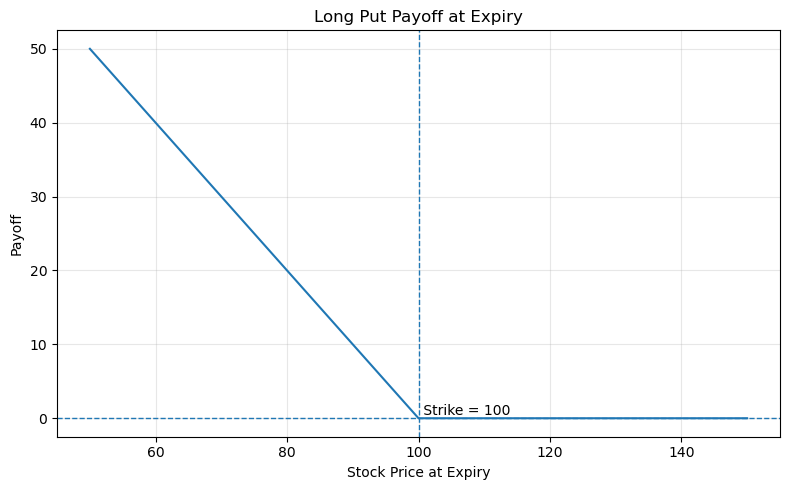

Saved: /Users/kedarvanikar/Downloads/option-market-frictions-hedging-error-lab-phase-1/figures/put_payoff_graph.png


In [5]:
save_line_plot(
    stock_prices,
    put_payoffs,
    title="Long Put Payoff at Expiry",
    ylabel="Payoff",
    filename="put_payoff_graph.png",
    strike=strike,
)


## Long Call Profit

Profit includes the premium paid to enter the position. For the long call, the breakeven stock price is the strike plus the premium.


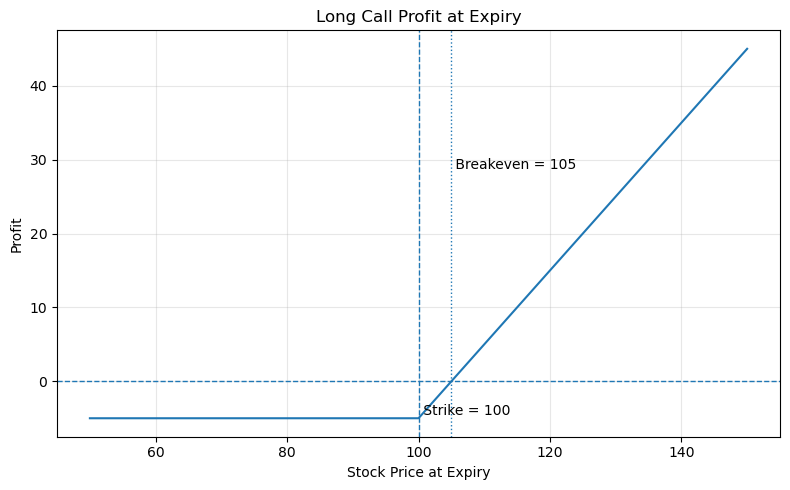

Saved: /Users/kedarvanikar/Downloads/option-market-frictions-hedging-error-lab-phase-1/figures/call_profit_graph.png


In [6]:
save_line_plot(
    stock_prices,
    call_profits,
    title="Long Call Profit at Expiry",
    ylabel="Profit",
    filename="call_profit_graph.png",
    strike=strike,
    breakeven=call_breakeven,
)


## Long Put Profit

For the long put, the breakeven stock price is the strike minus the premium. Below that point, the position is profitable at expiry.


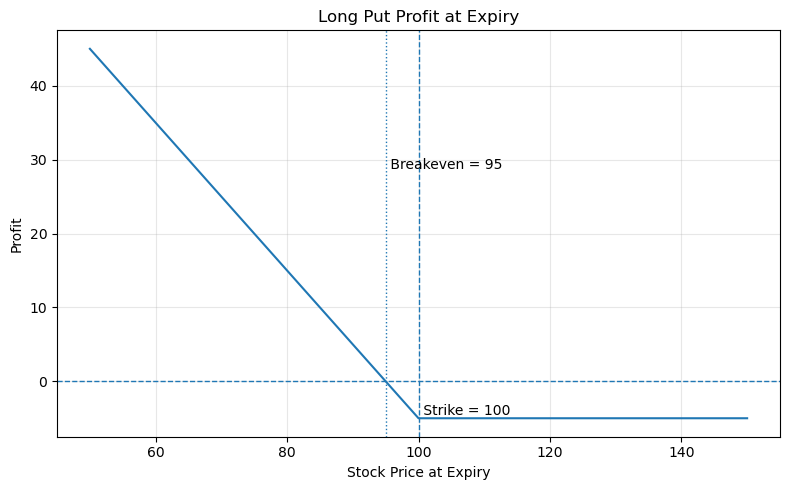

Saved: /Users/kedarvanikar/Downloads/option-market-frictions-hedging-error-lab-phase-1/figures/put_profit_graph.png


In [7]:
save_line_plot(
    stock_prices,
    put_profits,
    title="Long Put Profit at Expiry",
    ylabel="Profit",
    filename="put_profit_graph.png",
    strike=strike,
    breakeven=put_breakeven,
)


## Notes

The main takeaway from these graphs is that option payoffs are not linear in the same way stock ownership is. The bend around the strike is what makes options sensitive to changes in the underlying price in a more complex way. Later in the project, this same nonlinearity will connect directly to Delta, Gamma, and hedging error.
